# Approximate Hybrid Quantum State Preparation for a Multi-Gaussian Signal

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

## Signal Generation
We construct a synthetic signal composed of multiple sinusoidal components in order to study sparse Fourier representations.

In [3]:
n = 15 # Number of qubit
N = 2**n  # Number of quantum basis

x  = np.linspace(-5, 5, N)
rng = np.random.default_rng(42)  # reproducible example

K = 12  # number of Gaussians
mus    = rng.uniform(-4.5, 4.5, size=K)   # centers
sigmas = rng.uniform(0.12, 0.60, size=K)  # widths
amps   = rng.uniform(0.30, 1.00, size=K)  # amplitudes

g = np.zeros_like(x)
for a, m, s in zip(amps, mus, sigmas):
    g += a * np.exp(-(x - m)**2 / (2.0 * s**2))

# small noise
g += 0.001 * rng.standard_normal(N)

target_f =  g / np.linalg.norm(g)

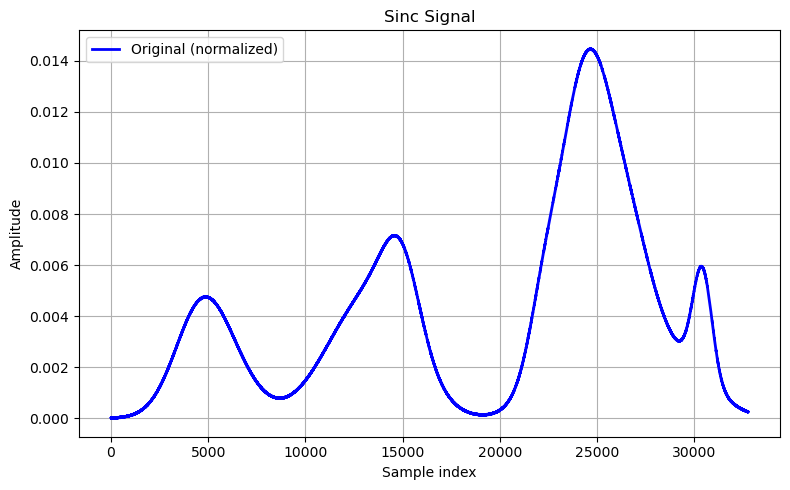

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, label="Original (normalized)", lw=2, color="blue")

plt.title(f"Sinc Signal")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

## Phase I: Compression of the Piecewise Constant Signal
### Classical Sparsity Analysis

The transform-domain coefficients are analyzed in order to identify sparse representations suitable for quantum state preparation.

In [5]:
results = search_sparse_haar_representations(
    g,
    tolerance=0.04
)

Level=7 | Threshold=3.028e-02 | Nonzero=762 | Sparsity=0.023 | Trace Distance=2.370308e-03 | Fidelity=0.999994
Level=7 | Threshold=6.055e-02 | Nonzero=550 | Sparsity=0.017 | Trace Distance=4.251987e-03 | Fidelity=0.999982
Level=7 | Threshold=1.514e-01 | Nonzero=329 | Sparsity=0.010 | Trace Distance=9.062364e-03 | Fidelity=0.999918
Level=7 | Threshold=3.028e-01 | Nonzero=249 | Sparsity=0.008 | Trace Distance=1.433185e-02 | Fidelity=0.999795
Level=7 | Threshold=6.055e-01 | Nonzero=229 | Sparsity=0.007 | Trace Distance=1.781293e-02 | Fidelity=0.999683
Level=7 | Threshold=1.514e+00 | Nonzero=210 | Sparsity=0.006 | Trace Distance=2.981589e-02 | Fidelity=0.999111
Level=8 | Threshold=4.278e-02 | Nonzero=501 | Sparsity=0.015 | Trace Distance=2.584577e-03 | Fidelity=0.999993
Level=8 | Threshold=8.555e-02 | Nonzero=377 | Sparsity=0.012 | Trace Distance=4.633269e-03 | Fidelity=0.999979
Level=8 | Threshold=2.139e-01 | Nonzero=243 | Sparsity=0.007 | Trace Distance=1.015055e-02 | Fidelity=0.999897
L

In [6]:
# Apply 10-level discrete packet Haar wavelet transformation on sinc signal
level = 12
X = haar_packet_transform(g, level)

In [7]:
# apply top-k threshold on the transformed data for k =110

k = 100
Xr = top_k_threshold(X, k)

### Normalization

In [8]:
X_norm = Xr/np.linalg.norm(Xr)

### Classical Signal Reconstruction

In [9]:
x_rec = inverse_haar_packet_transform(X_norm, level)

### Trace Distance

In [10]:
TD = trace_distance(x_rec, target_f)

### Visualization

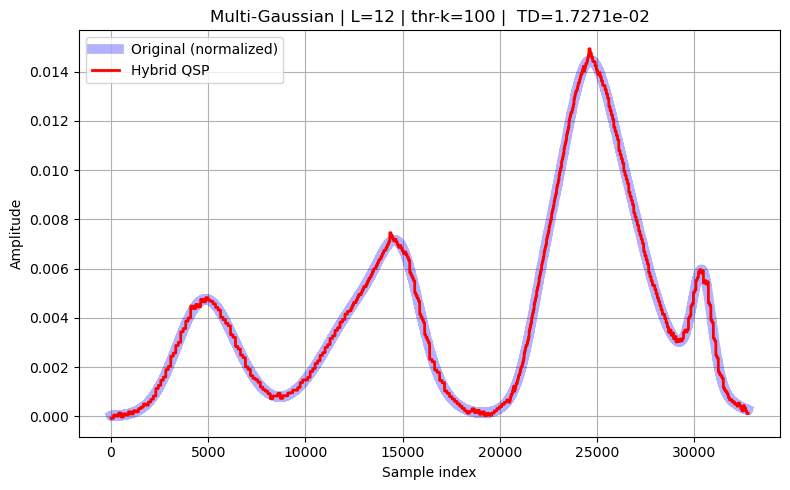

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(x_rec, lw=2, color="red", label="Hybrid QSP")
plt.title(f"Multi-Gaussian | L={level} | thr-k={k} |  TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();

plt.savefig("../figures/Multi-Gaussian_signal_preparation.pdf")
plt.show()

## Phase II: Quantum Decompression
The sparse Haar-domain representation is normalized and encoded into a quantum state. The inverse Quantum Packet Haar Wavelet Transform is then applied in order to reconstruct the original signal quantum mechanically.

In [12]:
from qibo import Circuit, gates
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [13]:
# Sparse transform-domain coefficient vector
vec = X_norm

# Indices of nonzero coefficients
nz = np.flatnonzero(vec)

# Total number of qubits required
# for amplitude encoding
nqubits = int(np.log2(len(vec)))

# Construct sparse basis-state representation
# as (bitstring, amplitude) pairs
y = [
    (format(i, f"0{nqubits}b"), vec[i])
    for i in nz
]

# Prepare sparse quantum state using
# the Farias SQSP method
qc = sparse_encoder(
    y,
    method="farias"
)

# Construct inverse quantum Haar packet
# wavelet transform circuit
iqphwt = build_inverse_qphwt_circuit(
    n=nqubits,
    level=level
)

# Apply inverse quantum transformation
# for signal reconstruction
qc.add(
    iqphwt.on_qubits(*range(nqubits))
)

# Display decomposed circuit statistics
# for quantum resource analysis
print(
    qc.decompose().decompose().summary()
)

[Qibo 0.3.3|INFO|2026-05-27 22:45:57]: Using numpy backend on /CPU:0


Circuit depth = 732
Total number of gates = 1207
Number of qubits = 15
Most common gates:
cx: 722
x: 216
ry: 213
h: 56
None


## Statevector of the Quantum SQSP and Quantum Decompression

In [14]:
result = qc()

state = result.state()

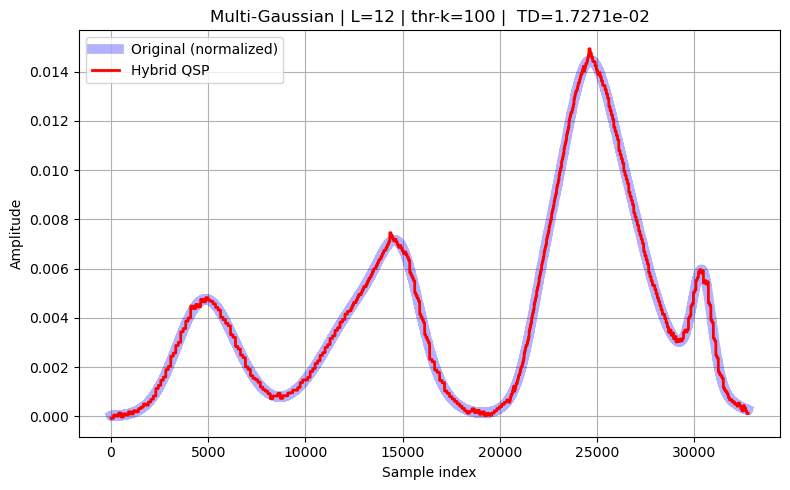

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(state.real, lw=2, color="red", label="Hybrid QSP")
plt.title(f"Multi-Gaussian | L={level} | thr-k={k} |  TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()